In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Đọc cả 2 tập dữ liệu
df_mat = pd.read_csv('Data/student-mat.csv', sep=';')
df_por = pd.read_csv('Data/student-por.csv', sep=';')

# Thêm cột 'subject'
df_mat['subject'] = 'Math'
df_por['subject'] = 'Por'

# Gộp 2 DataFrame lại theo chiều dọc
df = pd.concat([df_mat, df_por], ignore_index=True)

print(f"Tổng số học sinh: {df.shape[0]}")

Tổng số học sinh: 1044


In [2]:
df_processed = df.copy()

# TẠO BIẾN MỤC TIÊU MỚI: Pass (1) nếu G3 >= 10, ngược lại Fail (0)
df_processed['Pass'] = df_processed['G3'].apply(lambda x: 1 if x >= 10 else 0)

# Xử lý biến phân loại (Categorical)
categorical_cols = df_processed.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])

# Phân chia Features (X) và Target (y)
# LƯU Ý: Phải drop cả G1, G2 (tránh data leakage) và G3 (vì ta đã có cột 'Pass' thay thế)
X = df_processed.drop(['G1', 'G2', 'G3', 'Pass'], axis=1)
y = df_processed['Pass'] # Cột mục tiêu lúc này là Pass/Fail

# Chia tập Train (80%) và Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Xem tỷ lệ Đỗ/Trượt trong tập dữ liệu
print("Tỷ lệ Đỗ/Trượt trong dữ liệu gốc:")
print(y.value_counts(normalize=True) * 100)

Tỷ lệ Đỗ/Trượt trong dữ liệu gốc:
Pass
1    77.969349
0    22.030651
Name: proportion, dtype: float64


In [3]:
# Khởi tạo mô hình Logistic Regression
classifier_model = LogisticRegression(random_state=42, max_iter=1000)

# Huấn luyện mô hình
classifier_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập Test
y_pred = classifier_model.predict(X_test_scaled)

In [4]:
# Tính độ chính xác tổng thể
accuracy = accuracy_score(y_test, y_pred)

print(f"Độ chính xác (Accuracy): {accuracy * 100:.2f}%\n")

# In báo cáo phân loại chi tiết
print("BÁO CÁO PHÂN LOẠI (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['Fail (0)', 'Pass (1)']))

Độ chính xác (Accuracy): 71.77%

BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

    Fail (0)       0.52      0.25      0.34        60
    Pass (1)       0.75      0.91      0.82       149

    accuracy                           0.72       209
   macro avg       0.63      0.58      0.58       209
weighted avg       0.68      0.72      0.68       209



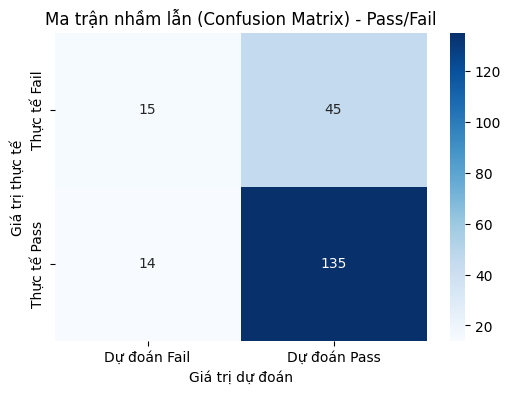

In [5]:
# Tính toán Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Vẽ biểu đồ Heatmap cho Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Dự đoán Fail', 'Dự đoán Pass'], 
            yticklabels=['Thực tế Fail', 'Thực tế Pass'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Pass/Fail')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()